# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://eu.api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
KAKAO_API_KEY = os.getenv("KAKAO_API_KEY")

## 카카오 장소검색 도구

https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [2]:
from langchain.tools import tool
import requests
from pprint import pprint
from typing import List, TypedDict

class KakaoPlace(TypedDict):
    name: str
    address: str
    url: str

@tool
def kakao_place_search(query: str) -> List[KakaoPlace]:
    """
    카카오 장소검색 API를 호출하기 위한 도구
    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization': f'KakaoAK {KAKAO_API_KEY}'
    }
    params = {
        'query': query,
        'size': 5
    }
    response = requests.get(url, headers=headers, params=params)
    data = response.json()
    data = data['documents']

    return [
        {
            'name': place['place_name'],
            'address': place['address_name'],
            'url': place['place_url']
        }
        for place in data
    ]

pprint(kakao_place_search.invoke({'query': '독산역 맛집'}))

c:\Users\Playdata\nlp\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'address': '서울 금천구 가산동 685',
  'name': '도원',
  'url': 'http://place.map.kakao.com/1713311171'},
 {'address': '서울 금천구 독산동 1006-187',
  'name': '고향통닭',
  'url': 'http://place.map.kakao.com/236210908'},
 {'address': '서울 금천구 가산동 673',
  'name': '히나타',
  'url': 'http://place.map.kakao.com/1788547704'},
 {'address': '서울 금천구 가산동 691-3',
  'name': '천우돈',
  'url': 'http://place.map.kakao.com/1425439504'},
 {'address': '서울 금천구 가산동 680',
  'name': '좋은데',
  'url': 'http://place.map.kakao.com/382341238'}]


키워드추출

In [3]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate


llm =  init_chat_model('openai:gpt-4.1-mini')

@tool
def extract_keyword(user_request: str) -> str:  # 사용자 요청을 장소검색 키워드로 변환하는 도구
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    prompt = PromptTemplate.from_template('''
    당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
    장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
    - 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
    - 다른 설명은 하지말고, 키워드만 추출합니다.

    [사용자요청]
    {user_request}


    [예시]
    - 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
    - 부산 핫플 좀 알려줘봐 -> 부산 맛집

    [금지어]
    - 소문난
    - 핫플
    ''')
    chain = prompt | llm
    response = chain.invoke({'user_request': user_request})
    return response.content.strip('"').strip("'")

In [4]:
print(extract_keyword.invoke('여기 독산동인데, 소문난 맛집좀 알려줘봐'))  # 지역+의도 키워드 추출
print(extract_keyword.invoke('이따 명동 갈건데, 맛집 리스트 좀 뽑아줘'))  # 장소 기반 맛집 키워드
print(extract_keyword.invoke('부산 핫플 좀 알려줘봐'))  # 금지어 제거 후 키워드
print(extract_keyword.invoke('강남에서 디저트 어디서 먹을까?'))  # 카테고리형 키워드
print(extract_keyword.invoke('수원에 호텔 어디가 좋아?'))  # 숙박 카테고리 키워드
print(extract_keyword.invoke('경기도 광주에 세차장 좀 찾아줘'))  # 업종 검색 키워드

독산동 맛집
명동 맛집
부산 관광 명소 인기 장소
강남 디저트 맛집
수원 호텔
경기도 광주 세차장


## 그래프 구성

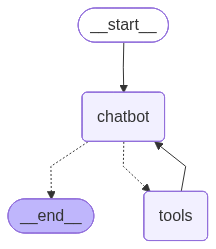

In [ ]:
# 사용자 입력 -> 키워드 추출 -> 카카오 장소검색 -> 상태(State)에 결과 저장하는 LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages   
from typing import Annotated, Optional
from langchain_core.messages import BaseMessage, ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition    # 도구노드 / 분기조건

# 그래프 상태 스키마
class State(TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]
    search_query : Optional[str]
    search_results : Optional[List[KakaoPlace]]             # 도구 스펙 바인딩
    
model = init_chat_model('openai:gpt-4.1-mini')
tools = [kakao_place_search,extract_keyword]
model_with_tools = model.bind_tools(tools)

def chatbot(state:State):
    if isinstance(state['messages'][-1],ToolMessage):               # 빅전에 도구 실행 결과가 들어온 경우
        if state['messages'][-1].name == 'extract_keyword':         # 키워드 추출 도구이면
            state['search_query'] = state['messages'][-1].content   # 검색 키워드 저장
        elif state['messages'][-1].name == 'kakao_place_search':    # 장소 검색 도구이면
            state['search_results'] = state['messages'][-1].content # 검색 결과 저장
            
    response = model_with_tools.invoke(state['messages'])           # 누적 메시지로 LLM 호출
    return {**state, 'messages':[response]}                         

workflow = StateGraph(State)

workflow.add_node('chatbot',chatbot)
workflow.add_node('tools',ToolNode(tools))

workflow.add_edge(START, 'chatbot')
workflow.add_conditional_edges('chatbot',tools_condition)   # tool call 필요시 tools, 아니면 END로 분기
workflow.add_edge('tools','chatbot')    # 후속 응답 생성

graph = workflow.compile()
graph

## 그래프 실행

In [6]:
initial_state : State={
    'messages' : [('human', '망우동 맛집 추천해줘')],
    'search_query' : None,
    'search_results' : None
}

final_state = graph.invoke(initial_state)
final_state

{'messages': [HumanMessage(content='망우동 맛집 추천해줘', additional_kwargs={}, response_metadata={}, id='bd51b864-0ef6-49d1-9657-68b8bea18ef5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 139, 'total_tokens': 161, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_82dbabdb2c', 'id': 'chatcmpl-D7ano4Q5p7d7o8eICqVMt8XEW2veP', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c4612-6262-7a91-b09a-c056ebe2dbd0-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '망우동 맛집 추천해줘'}, 'id': 'call_jnh3ib9JMsv6LLOA98cpHQFs', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 139, 'ou

In [7]:
from IPython.display import Markdown

Markdown(final_state['messages'][-1].content)

망우동 맛집으로 다음 곳들을 추천합니다:
1. 홍이네옛날떡볶이 - 서울 중랑구 망우동 342-47 [지도보기](http://place.map.kakao.com/16061905)
2. 용마해장국 - 서울 중랑구 망우동 406-1 [지도보기](http://place.map.kakao.com/16704031)
3. 망우찜쌈밥 본점 - 서울 중랑구 망우동 410-2 [지도보기](http://place.map.kakao.com/1012088848)
4. 능이마을 망우직영점 - 서울 중랑구 망우동 470-30 [지도보기](http://place.map.kakao.com/1228588130)
5. 그린플레이트 신내점 - 서울 중랑구 망우동 584 [지도보기](http://place.map.kakao.com/26458645)

원하는 음식 종류나 분위기가 있으면 더 추천해 드릴 수 있어요!

## 그래프 디버깅

In [8]:
for msg in final_state['messages']:
    msg.pretty_print()

================================ Human Message =================================

망우동 맛집 추천해줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_jnh3ib9JMsv6LLOA98cpHQFs)
 Call ID: call_jnh3ib9JMsv6LLOA98cpHQFs
  Args:
    user_request: 망우동 맛집 추천해줘
================================= Tool Message =================================
Name: extract_keyword

망우동 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_xKBHfVNZITryioRFiJXvjVia)
 Call ID: call_xKBHfVNZITryioRFiJXvjVia
  Args:
    query: 망우동 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "홍이네옛날떡볶이", "address": "서울 중랑구 망우동 342-47", "url": "http://place.map.kakao.com/16061905"}, {"name": "용마해장국", "address": "서울 중랑구 망우동 406-1", "url": "http://place.map.kakao.com/16704031"}, {"name": "망우찜쌈밥 본점", "address": "서울 중랑구 망우동 410-2", "url":

In [ ]:
# LangGraph 스트리밍 실행 : 노드별 실행 결과를 실시간으로 확인
initial_state : State={
    'messages':[('human','상봉역과 망우역 사이 맛집 추천해줘')],
    'search_query':None,        # 키워드 추출
    'search_results':None       # 장소 검색 결과
}

# 그래프를 스트리밍 방식으로 실행(stream_mode='updates' 기본값으로 노드 실행이 끝날때마다 중간 결과를 전달)
for chunk in graph.stream(initial_state, stream_mode='updates'):
    for node, update in chunk.items():  # chunk (실행된 노드, 해당 업데이트) 순회
        print(f'{node}node')
        update['messages'][-1].pretty_print()
    print()

chatbotnode
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_qvjhnwFqzNU8f4Hbsmw9PCKk)
 Call ID: call_qvjhnwFqzNU8f4Hbsmw9PCKk
  Args:
    user_request: 상봉역과 망우역 사이 맛집 추천해줘
  extract_keyword (call_yH1zj9HpsHHzb9PGXdYHPWVf)
 Call ID: call_yH1zj9HpsHHzb9PGXdYHPWVf
  Args:
    user_request: 상봉역과 망우역 사이 맛집 추천해줘

toolsnode
================================= Tool Message =================================
Name: extract_keyword

상봉역 망우역 맛집

chatbotnode
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_L9twenpHmdEwacJSzsc8R1UO)
 Call ID: call_L9twenpHmdEwacJSzsc8R1UO
  Args:
    query: 상봉역 망우역 맛집

toolsnode
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "뚜레쥬르 망우역점", "address": "서울 중랑구 상봉동 81-5", "url": "http://place.map.kakao.com/319465892"}, {"name": "투썸플레이스 망우역사거리점", "address": "서울 중랑구 망우동